In [9]:
using Distributions
using Random
using JuMP 
using LinearAlgebra
using Ipopt
using Plots

$$
\begin{cases}
y = - x \beta + u_1 \\
x = z \gamma + u _2
\end{cases}
$$

In matricial form with $Y = \begin{bmatrix} y & x \end{bmatrix}$,

$$
Y \begin{bmatrix} 1 & 0 \\ \beta & 1 \end{bmatrix} = z \begin{bmatrix} 0 & \gamma  \end{bmatrix} + U 
$$

The LIML objective function is

$$
Q(\beta) = \frac{b'Y' P Y b}{b'Y' M Y b}
$$

In [94]:
beta = 5 ; gamma = 1  ; n = 1000

B = [ 1 0 ;  beta 1  ] ;  Gamma = [0 gamma] ; Σ =  [2 1; 1 2]

Random.seed!(126) ; z = rand(n, 1); U = rand( MvNormal(zeros(2) , Σ  ) , n  )' ; Y = z * Gamma * inv(B) + U*inv(B) ; 

P = z * inv(z' * z) * z' ; M = Matrix(I, n , n) - P ; 

values, vectors = eigen(Y' *P *Y, Y'* M* Y)

function Q(beta)
    b = [1 , beta]
    num = b' * Y' *P *Y * b
    den = b' * Y' *M *Y * b
    return num/den
end    

Q_max = values[2]
Q_min = values[1]

function h(β)
  return  β/( Q_max - β)
end

function L0(β)
  return  Q(β) + β^2
end

function L(β)
  return  h(Q(β)) + β^2
end

# Otimização livre

model = Model(Ipopt.Optimizer)
set_silent(model)                    

@variable(model, β,  start = 20)   

register(model, :Q, 1, Q; autodiff = true)

@NLobjective(model, Min, Q(β) ) 

optimize!(model)

sol = value(β) ; 




5.080751971117561

In [109]:
# Método do Miguel

λ = 0.5

function LM(β)
    return  Q(β) + λ * β^2/(1 + β^2)
  end


  model = Model(Ipopt.Optimizer)
set_silent(model)                    

@variable(model, β,  start = 20)   

register(model, :LM, 1, LM; autodiff = true)

@NLobjective(model, Min, LM(β) ) 

optimize!(model)

sol = value(β)



5.06309130747224

In [111]:
# Método do Miguel

λ = 3

function LM(β)
    return  Q(β) + λ * ( Q(0) - Q_min ) *  β^2/(1 + β^2)
end


  model = Model(Ipopt.Optimizer)
set_silent(model)                    

@variable(model, β,  start = 20)   

register(model, :LM, 1, LM; autodiff = true)

@NLobjective(model, Min, LM(β) ) 

optimize!(model)

sol = value(β)



-0.005791961938600821

In [105]:
Q(0) - Q_min

0.26702484106611

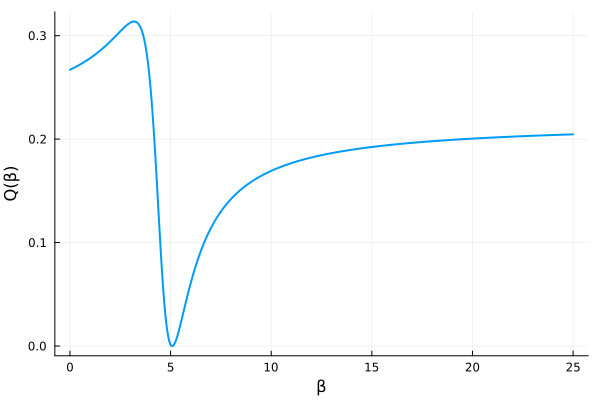

In [98]:
plot(0:0.01:25, Q.(0:0.01:25); 
xlabel="β", ylabel="Q(β)",
legend=false, lw=2)